Предмет "Искусственный интеллект"

Лабораторная работа №3

Грибушенков Михаил, группа РФЗ-2-2022

Регрессия для определения качества белого вина (зависимость параметра "quality" - экспертной оценка качества вина - от ряда объективных параметров).

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# defines
filename = "winequality-white[1].csv"

In [5]:
db = pd.read_csv (filename, sep=";") # Загрузка базы данных из файла
db.info() # Статистика по БД

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


Видно, что пропусков нет и все данные числовые.

In [6]:
db.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


Видно, что данные не нормализованы.

In [7]:
for column in db.columns:
    db[column] = db[column] / db[column].abs().max()

In [8]:
db.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,0.482732,0.252946,0.201320,0.097134,0.132290,0.122173,0.314456,0.956734,0.834625,0.453562,0.740441,0.653101
std,0.059427,0.091631,0.072903,0.077083,0.063144,0.058848,0.096587,0.002879,0.039529,0.105672,0.086663,0.098404
min,0.267606,0.072727,0.000000,0.009119,0.026012,0.006920,0.020455,0.950076,0.712042,0.203704,0.563380,0.333333
25%,0.443662,0.190909,0.162651,0.025836,0.104046,0.079585,0.245455,0.954515,0.808901,0.379630,0.669014,0.555556
50%,0.478873,0.236364,0.192771,0.079027,0.124277,0.117647,0.304545,0.956457,0.832461,0.435185,0.732394,0.666667
75%,0.514085,0.290909,0.234940,0.150456,0.144509,0.159170,0.379545,0.958729,0.858639,0.509259,0.802817,0.666667
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Нормализованное.

<Axes: >

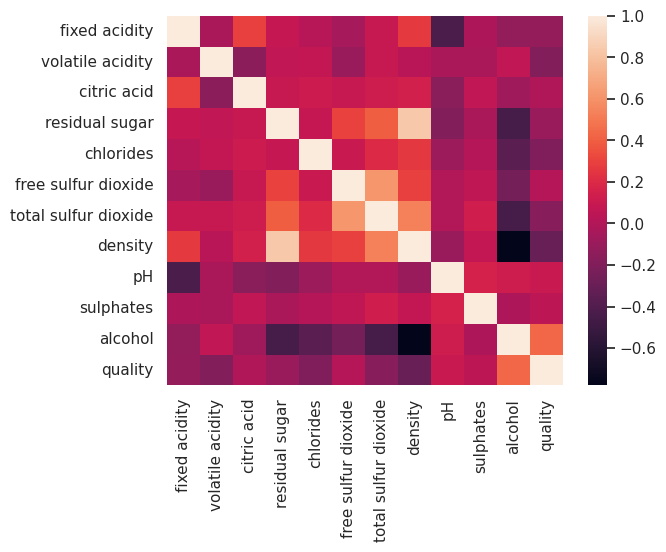

In [9]:
sns.heatmap(db.corr(numeric_only = True))

Видно, что с субъективной оценкой quality сильнее всего коррелирует крепость вина, прочее коррелирует примерно одинаково, кроме pH, от которого оценнка почти не зависит.

In [10]:
# Деление набора данных на тестовый и обучающий, статистика сего.
from sklearn.model_selection import train_test_split
import scipy.stats as stats

features = db.drop(["quality"], axis=1)
target = db["quality"]
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.30, random_state=42)

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score

from sklearn import metrics
from collections import Counter

# Функция для рассчета и вывода метрик
def metrics1111 (model,X_train,y_train,X_test,y_test,y_pred):
    cv_score = cross_val_score(estimator = model, X = X_train, y = y_train, cv = 10)
#
    r2 = model.score(X_test, y_test)
#
    n = X_test.shape[0]
    p = X_test.shape[1]
    adjusted_r2 = 1-(1-r2)*(n-1)/(n-p-1)
#
    RMSE = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
#
    CV_R2 = cv_score.mean()

    print(f'-- МЕТРИКИ --\nRMSE:  {round(RMSE,4)}\n  R2: {round(r2,4)}\n Adjusted R2: {round(adjusted_r2, 4)}\n Cross Validated R2: {round(CV_R2,4)}')


In [12]:
# Линейная регрессия

from sklearn.linear_model import LinearRegression

LR = LinearRegression()
LR.fit(features_train, target_train)
target_predicted = LR.predict(features_test)
metrics1111 (LR, features_train, target_train, features_test, target_test, target_predicted)

-- МЕТРИКИ --
RMSE:  0.0827
  R2: 0.2659
 Adjusted R2: 0.2603
 Cross Validated R2: 0.275


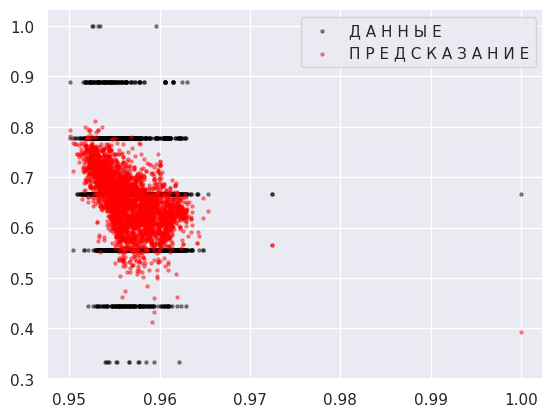

In [29]:
plt.scatter(features_train["density"], target_train, color='black',
            label='Д А Н Н Ы Е', s = 5, alpha=0.4)
plt.scatter(features_train["density"], LR.predict(features_train), color='red',
         label='П Р Е Д С К А З А Н И Е', s = 5, alpha = 0.4)
plt.legend()
plt.show()

Для нормализованной оценки в диапазоне 0 - 1.00 получена оценка с RMSE в 0.0827, это хорошо : )

In [13]:
# Регрессор дерева принятия решений

from sklearn.tree import DecisionTreeRegressor

DT = DecisionTreeRegressor()
DT.fit(features_train, target_train)
target_predicted = DT.predict(features_test)

metrics1111 (DT, features_train, target_train, features_test, target_test, target_predicted)

-- МЕТРИКИ --
RMSE:  0.0947
  R2: 0.0377
 Adjusted R2: 0.0305
 Cross Validated R2: 0.0485


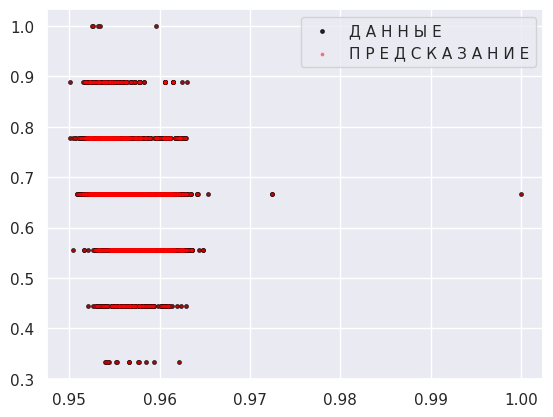

In [32]:
plt.scatter(features_train["density"], target_train, color='black',
            label='Д А Н Н Ы Е', s = 6, alpha=0.8)
plt.scatter(features_train["density"], DT.predict(features_train), color='red',
         label='П Р Е Д С К А З А Н И Е', s = 3, alpha = 0.4)
plt.legend()
plt.show()

RMSE хуже, чем для линейной регрессии. Зато значения предсказанные совпали с числами из реальных оценок.

In [15]:
# Регрессор на лесе случайных деревьев

from sklearn.ensemble import RandomForestRegressor

RF = RandomForestRegressor(n_estimators=100)
RF.fit(features_train, target_train)
target_predicted = RF.predict(features_test)

metrics1111 (RF, features_train, target_train, features_test, target_test, target_predicted)

-- МЕТРИКИ --
RMSE:  0.067
  R2: 0.519
 Adjusted R2: 0.5154
 Cross Validated R2: 0.4891


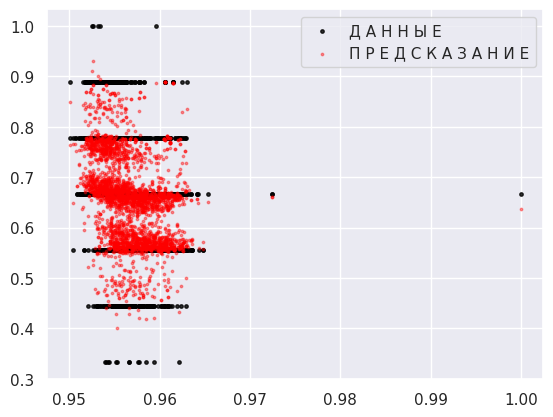

In [33]:
plt.scatter(features_train["density"], target_train, color='black',
            label='Д А Н Н Ы Е', s = 6, alpha=0.8)
plt.scatter(features_train["density"], RF.predict(features_train), color='red',
         label='П Р Е Д С К А З А Н И Е', s = 3, alpha = 0.4)
plt.legend()
plt.show()

RMSE лучше, чем для линейной регрессии. Новый рекорд. Но выполнялось долго, около двух минут.

In [37]:
# Регрессор на опорных векторах с линейным ядром

from sklearn.svm import SVR

modelSVR1 = SVR(kernel='linear')
modelSVR1.fit(features_train, target_train)
target_predicted = modelSVR1.predict(features_test)

metrics1111 (modelSVR1, features_train, target_train, features_test, target_test, target_predicted)

-- МЕТРИКИ --
RMSE:  0.0836
  R2: 0.2502
 Adjusted R2: 0.2445
 Cross Validated R2: 0.2657


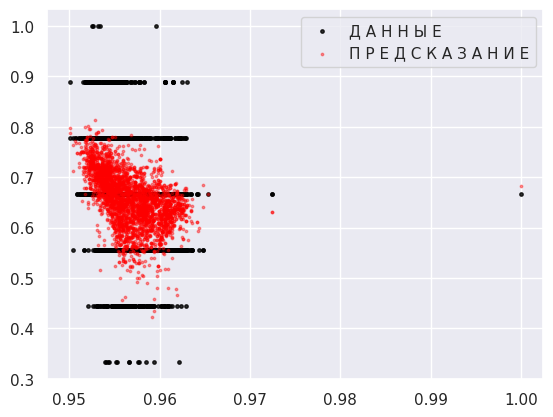

In [38]:
plt.scatter(features_train["density"], target_train, color='black',
            label='Д А Н Н Ы Е', s = 6, alpha=0.8)
plt.scatter(features_train["density"], modelSVR1.predict(features_train), color='red',
         label='П Р Е Д С К А З А Н И Е', s = 3, alpha = 0.4)
plt.legend()
plt.show()

In [39]:
# Регрессор на опорных векторах с полиномиальным ядром

modelSVR2 = SVR(kernel='poly')
modelSVR2.fit(features_train, target_train)
target_predicted = modelSVR2.predict(features_test)

metrics1111 (modelSVR2, features_train, target_train, features_test, target_test, target_predicted)

-- МЕТРИКИ --
RMSE:  0.0894
  R2: 0.1421
 Adjusted R2: 0.1356
 Cross Validated R2: 0.3233


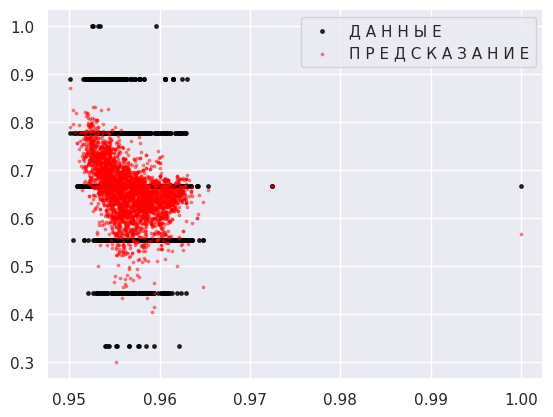

In [40]:
plt.scatter(features_train["density"], target_train, color='black',
            label='Д А Н Н Ы Е', s = 6, alpha=0.8)
plt.scatter(features_train["density"], modelSVR2.predict(features_train), color='red',
         label='П Р Е Д С К А З А Н И Е', s = 3, alpha = 0.4)
plt.legend()
plt.show()

In [41]:
# Регрессор на опорных векторах с ядром из радиальной базисной функции, о как

modelSVR3 = SVR(kernel='rbf')
modelSVR3.fit(features_train, target_train)
target_predicted = modelSVR3.predict(features_test)

metrics1111 (modelSVR3, features_train, target_train, features_test, target_test, target_predicted)

-- МЕТРИКИ --
RMSE:  0.079
  R2: 0.3304
 Adjusted R2: 0.3253
 Cross Validated R2: 0.3281


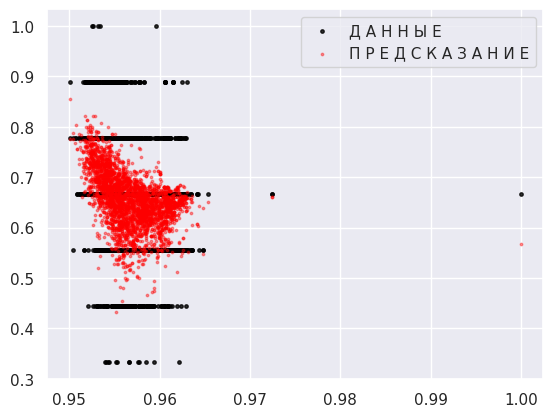

In [42]:
plt.scatter(features_train["density"], target_train, color='black',
            label='Д А Н Н Ы Е', s = 6, alpha=0.8)
plt.scatter(features_train["density"], modelSVR3.predict(features_train), color='red',
         label='П Р Е Д С К А З А Н И Е', s = 3, alpha = 0.4)
plt.legend()
plt.show()

In [46]:
# Регрессор на модели elasticnet

from sklearn.linear_model import ElasticNet

modelEN = ElasticNet(alpha=0.07, l1_ratio=0.4)
modelEN.fit(features_train, target_train)
target_predicted = modelEN.predict(features_test)

metrics1111 (modelEN, features_train, target_train, features_test, target_test, target_predicted)

-- МЕТРИКИ --
RMSE:  0.0966
  R2: -0.0012
 Adjusted R2: -0.0087
 Cross Validated R2: -0.003


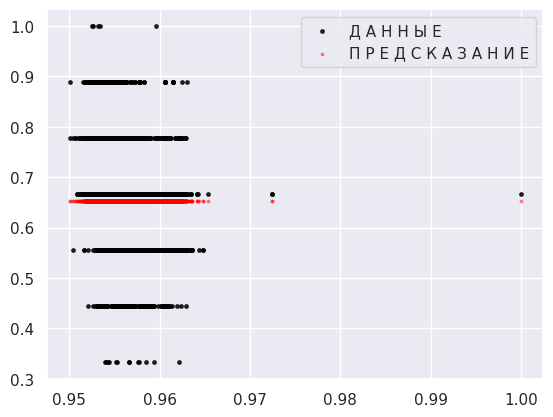

In [47]:
plt.scatter(features_train["density"], target_train, color='black',
            label='Д А Н Н Ы Е', s = 6, alpha=0.8)
plt.scatter(features_train["density"], modelEN.predict(features_train), color='red',
         label='П Р Е Д С К А З А Н И Е', s = 3, alpha = 0.4)
plt.legend()
plt.show()

Для всех данных равный результат, плллохо.

Итого лучшая среднеквадратичная ошибка у леса случайных деревьев, лучший коэффициент детерминации R^2 - у него же.